In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('..')
from src.visualization.plots import Visualizer
from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
# Load training data
print("="*60)
print("LOADING TRAINING DATA")
print("="*60)

train_path = '../data/raw/train.csv'
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    print(f"✅ Loaded training data: {df_train.shape}")
else:
    print(f"⚠️ Training data not found at {train_path}")
    print("📊 Generating sample data...")
    
    # Generate sample data
    np.random.seed(42)
    n_samples = 10000
    
    # Sample positive reviews
    positive_texts = [
        "Great product! Highly recommended.",
        "Excellent quality and fast shipping.",
        "Love this item, worth every penny.",
        "Amazing product, exceeded expectations.",
        "Perfect! Just what I needed.",
        "Five stars! Will buy again.",
        "Outstanding quality and service.",
        "Very satisfied with this purchase.",
        "Best product I've ever bought.",
        "Awesome! Works perfectly."
    ]
    
    # Sample negative reviews
    negative_texts = [
        "Terrible product, broke after one use.",
        "Waste of money, very disappointed.",
        "Poor quality, not worth the price.",
        "Awful! Doesn't work at all.",
        "Very bad experience, avoid this.",
        "Complete waste, regret buying.",
        "Disappointed with the quality.",
        "Not as described, very poor.",
        "Horrible product, falling apart.",
        "Worst purchase ever, stay away."
    ]
    
    # Generate data
    data = []
    for i in range(n_samples):
        if i < n_samples * 0.7:  # 70% positive
            label = 2
            text = np.random.choice(positive_texts)
            title = "Great product!"
        else:  # 30% negative
            label = 1
            text = np.random.choice(negative_texts)
            title = "Terrible product"
        
        # Add some variation
        if np.random.random() > 0.5:
            text += " " + np.random.choice([
                "Would recommend.",
                "Not sure about this.",
                "Maybe try something else.",
                "Definitely buying again.",
                "Very happy with it."
            ])
        
        data.append({
            'label': label,
            'title': title,
            'review_text': text
        })
    
    df_train = pd.DataFrame(data)
    print(f"✅ Generated sample data: {df_train.shape}")

# Load test data if exists
test_path = '../data/raw/test.csv'
if os.path.exists(test_path):
    df_test = pd.read_csv(test_path)
    print(f"✅ Loaded test data: {df_test.shape}")
else:
    # Create test data from train (20% split)
    from sklearn.model_selection import train_test_split
    df_train, df_test = train_test_split(df_train, test_size=0.2, random_state=42)
    print(f"✅ Created test data: {df_test.shape} (20% split)")

LOADING TRAINING DATA
⚠️ Training data not found at ../data/raw/train.csv
📊 Generating sample data...


✅ Generated sample data: (10000, 3)
✅ Created test data: (2000, 3) (20% split)


In [3]:
# Display basic info
print("\n" + "="*60)
print("DATA INFORMATION")
print("="*60)

print(f"\nTraining set: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")
print(f"Test set: {df_test.shape[0]:,} rows, {df_test.shape[1]} columns")

print("\n📋 Columns:")
for col in df_train.columns:
    print(f"  • {col}: {df_train[col].dtype}")

print("\n🔍 Missing values:")
print(df_train.isnull().sum())

print("\n📊 Basic statistics:")
print(df_train.describe(include='all'))


DATA INFORMATION

Training set: 8,000 rows, 3 columns
Test set: 2,000 rows, 3 columns

📋 Columns:
  • label: int64
  • title: object
  • review_text: object

🔍 Missing values:
label          0
title          0
review_text    0
dtype: int64

📊 Basic statistics:
              label           title                           review_text
count   8000.000000            8000                                  8000
unique          NaN               2                                   120
top             NaN  Great product!  Excellent quality and fast shipping.
freq            NaN            5591                                   305
mean       1.698875             NaN                                   NaN
std        0.458776             NaN                                   NaN
min        1.000000             NaN                                   NaN
25%        1.000000             NaN                                   NaN
50%        2.000000             NaN                                   Na

LABEL DISTRIBUTION

Label counts:
  • Label 1 (negative): 2,409 samples
  • Label 2 (positive): 5,591 samples

Percentages:
  • Negative: 30.1%
  • Positive: 69.9%


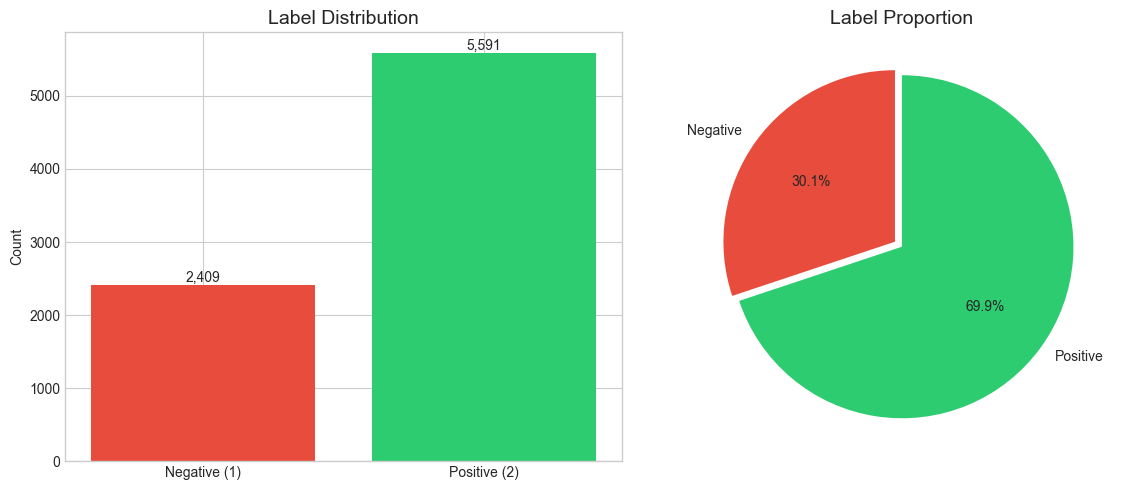

In [4]:
# Analyze label distribution
print("="*60)
print("LABEL DISTRIBUTION")
print("="*60)

label_counts = df_train['label'].value_counts().sort_index()
print(f"\nLabel counts:")
print(f"  • Label 1 (negative): {label_counts.get(1, 0):,} samples")
print(f"  • Label 2 (positive): {label_counts.get(2, 0):,} samples")

# Calculate percentages
total = len(df_train)
pct_negative = label_counts.get(1, 0) / total * 100
pct_positive = label_counts.get(2, 0) / total * 100
print(f"\nPercentages:")
print(f"  • Negative: {pct_negative:.1f}%")
print(f"  • Positive: {pct_positive:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
ax = axes[0]
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(['Negative (1)', 'Positive (2)'], 
              [label_counts.get(1, 0), label_counts.get(2, 0)],
              color=colors)
ax.set_title('Label Distribution', fontsize=14)
ax.set_ylabel('Count')

# Add value labels
for bar, count in zip(bars, [label_counts.get(1, 0), label_counts.get(2, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
           f'{count:,}', ha='center', va='bottom')

# Pie chart
ax = axes[1]
ax.pie([label_counts.get(1, 0), label_counts.get(2, 0)],
       labels=['Negative', 'Positive'],
       autopct='%1.1f%%',
       colors=colors,
       startangle=90,
       explode=(0.05, 0))
ax.set_title('Label Proportion', fontsize=14)

plt.tight_layout()
plt.show()

REVIEW LENGTH ANALYSIS

Review length statistics:
  • Mean: 6.4 words
  • Median: 6 words
  • Min: 3 words
  • Max: 10 words
  • Std: 2.0 words


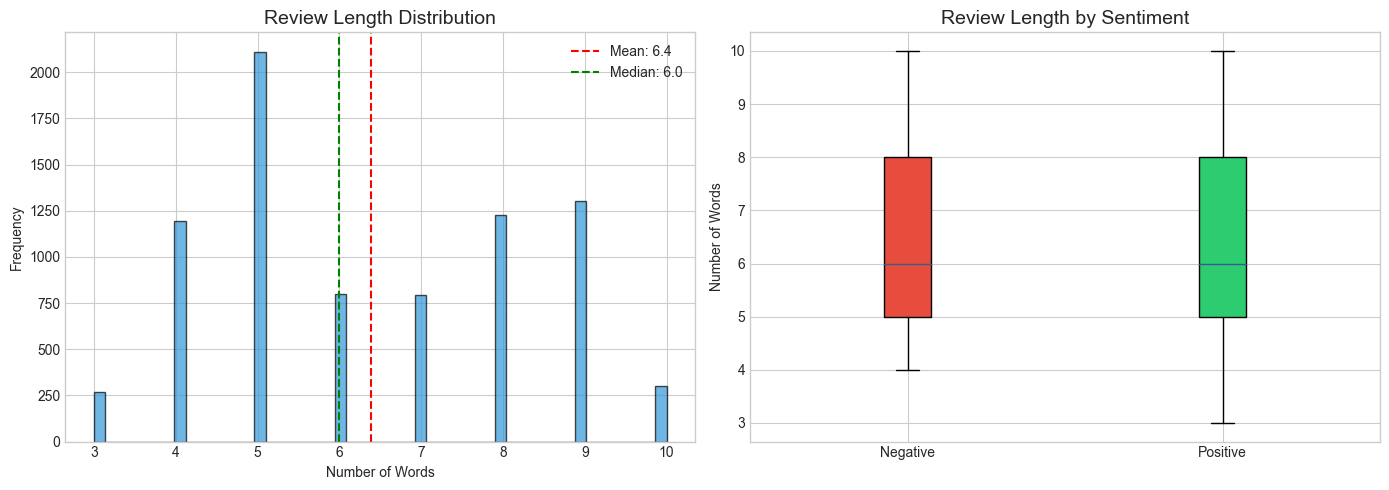

In [5]:
# Analyze review length
print("="*60)
print("REVIEW LENGTH ANALYSIS")
print("="*60)

# Calculate review lengths
df_train['review_length'] = df_train['review_text'].astype(str).str.split().str.len()

print(f"\nReview length statistics:")
print(f"  • Mean: {df_train['review_length'].mean():.1f} words")
print(f"  • Median: {df_train['review_length'].median():.0f} words")
print(f"  • Min: {df_train['review_length'].min()} words")
print(f"  • Max: {df_train['review_length'].max():,} words")
print(f"  • Std: {df_train['review_length'].std():.1f} words")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df_train['review_length'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax.axvline(df_train['review_length'].mean(), color='red', linestyle='--', 
           label=f"Mean: {df_train['review_length'].mean():.1f}")
ax.axvline(df_train['review_length'].median(), color='green', linestyle='--', 
           label=f"Median: {df_train['review_length'].median():.1f}")
ax.set_title('Review Length Distribution', fontsize=14)
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()

# Boxplot by label
ax = axes[1]
data_to_plot = [
    df_train[df_train['label'] == 1]['review_length'].values,
    df_train[df_train['label'] == 2]['review_length'].values
]
bp = ax.boxplot(data_to_plot, labels=['Negative', 'Positive'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
ax.set_title('Review Length by Sentiment', fontsize=14)
ax.set_ylabel('Number of Words')

plt.tight_layout()
plt.show()

TITLE ANALYSIS

Title length statistics:
  • Mean: 14.6 characters
  • Median: 14 characters

📊 Most common titles:
  • 'Great product!...' : 5,591 times
  • 'Terrible product...' : 2,409 times


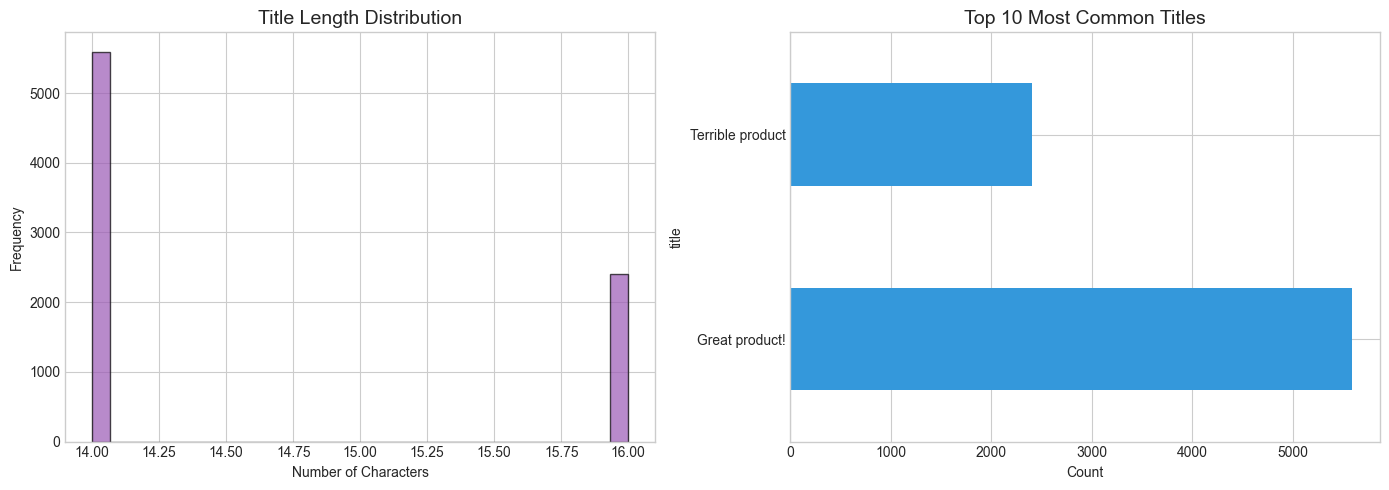

In [6]:
# Analyze titles
print("="*60)
print("TITLE ANALYSIS")
print("="*60)

# Title length
df_train['title_length'] = df_train['title'].astype(str).str.len()

print(f"\nTitle length statistics:")
print(f"  • Mean: {df_train['title_length'].mean():.1f} characters")
print(f"  • Median: {df_train['title_length'].median():.0f} characters")

# Most common titles
print("\n📊 Most common titles:")
top_titles = df_train['title'].value_counts().head(10)
for title, count in top_titles.items():
    print(f"  • '{title[:30]}...' : {count:,} times")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title length distribution
ax = axes[0]
ax.hist(df_train['title_length'], bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
ax.set_title('Title Length Distribution', fontsize=14)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')

# Top titles bar chart
ax = axes[1]
top_titles.head(10).plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 10 Most Common Titles', fontsize=14)
ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

WORD CLOUD - ALL REVIEWS


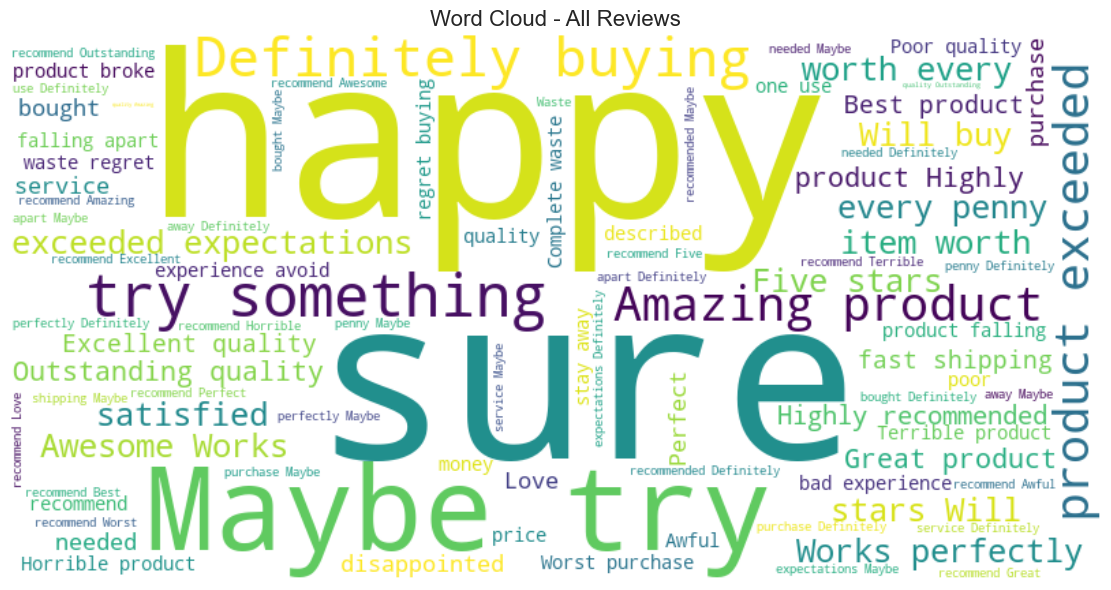

In [7]:
# Generate word cloud for all reviews
print("="*60)
print("WORD CLOUD - ALL REVIEWS")
print("="*60)

# Combine all review text
all_text = ' '.join(df_train['review_text'].astype(str).tolist())

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis',
    contour_width=1,
    contour_color='steelblue'
).generate(all_text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud - All Reviews', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

WORD CLOUDS BY SENTIMENT


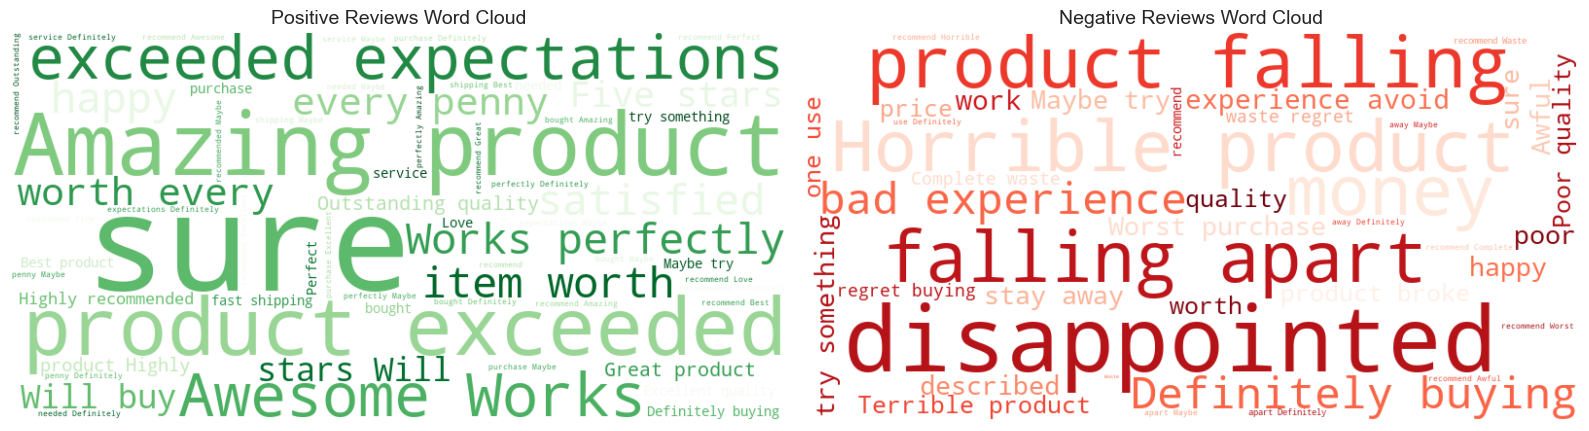

In [8]:
# Generate word clouds by sentiment
print("="*60)
print("WORD CLOUDS BY SENTIMENT")
print("="*60)

# Positive reviews
positive_text = ' '.join(df_train[df_train['label'] == 2]['review_text'].astype(str).tolist())
positive_wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='Greens',
    contour_width=1,
    contour_color='darkgreen'
).generate(positive_text)

# Negative reviews
negative_text = ' '.join(df_train[df_train['label'] == 1]['review_text'].astype(str).tolist())
negative_wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='Reds',
    contour_width=1,
    contour_color='darkred'
).generate(negative_text)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(positive_wordcloud, interpolation='bilinear')
axes[0].set_title('Positive Reviews Word Cloud', fontsize=14)
axes[0].axis('off')

axes[1].imshow(negative_wordcloud, interpolation='bilinear')
axes[1].set_title('Negative Reviews Word Cloud', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

MOST COMMON WORDS ANALYSIS

📊 Most common words overall:
   1. product         : 2,175 times
   2. very            : 2,135 times
   3. quality         : 1,559 times
   4. again           : 1,325 times
   5. not             : 1,289 times
   6. buying          : 984 times
   7. recommend       : 835 times
   8. sure            : 825 times
   9. happy           : 812 times
  10. purchase        : 808 times
  11. worth           : 786 times
  12. ever            : 779 times
  13. maybe           : 776 times
  14. try             : 776 times
  15. something       : 776 times
  16. else            : 776 times
  17. definitely      : 763 times
  18. amazing         : 581 times
  19. exceeded        : 581 times
  20. expectations    : 581 times

📊 Most common words in POSITIVE reviews:
   1. product         : 1,677 times
   2. very            : 1,139 times
   3. quality         : 1,114 times
   4. again           : 1,068 times
   5. not             : 590 times
   6. sure            : 590 times

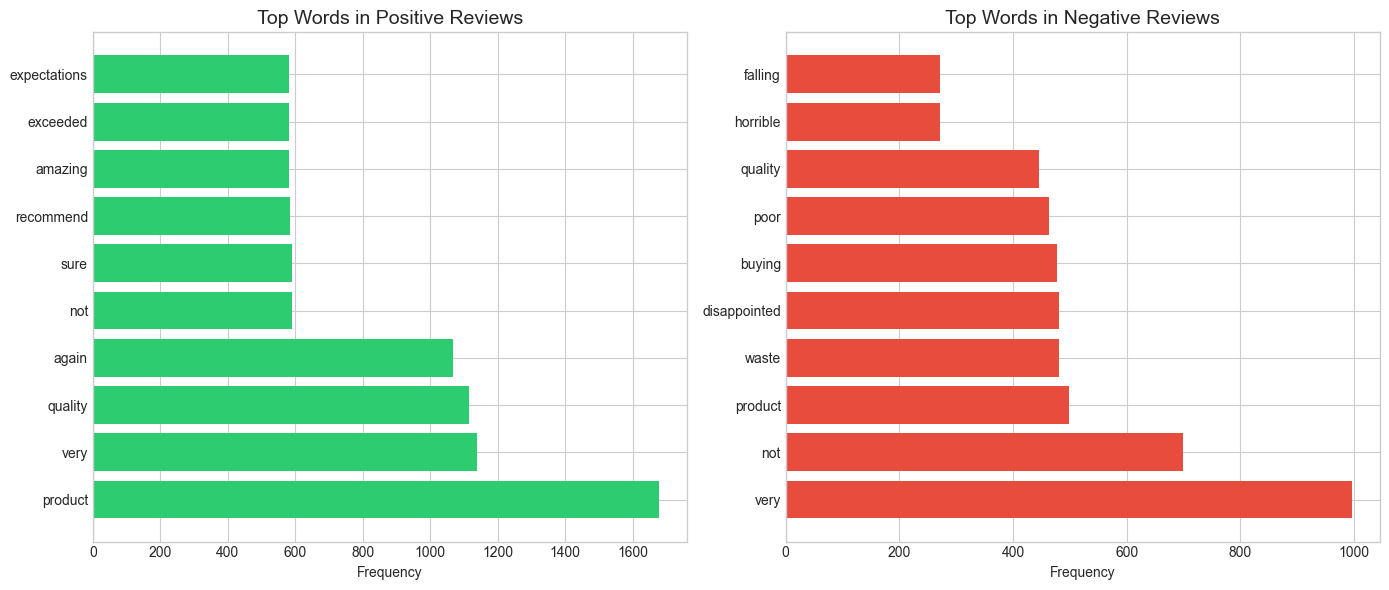

In [9]:
# Analyze most common words
from collections import Counter
import re

print("="*60)
print("MOST COMMON WORDS ANALYSIS")
print("="*60)

def get_most_common_words(texts, n=20):
    """Get most common words from list of texts"""
    # Combine all text and convert to lowercase
    all_text = ' '.join(texts).lower()
    # Remove punctuation and split
    words = re.findall(r'\b[a-z]+\b', all_text)
    # Remove common stopwords (basic list)
    stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                 'of', 'with', 'by', 'from', 'up', 'about', 'into', 'through', 'during',
                 'before', 'after', 'above', 'below', 'is', 'was', 'were', 'be', 'been',
                 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
                 'shall', 'should', 'may', 'might', 'must', 'can', 'could', 'i', 'you',
                 'he', 'she', 'it', 'we', 'they', 'them', 'their', 'my', 'your', 'his',
                 'her', 'its', 'our', 'their', 'this', 'that', 'these', 'those'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    # Count
    counter = Counter(words)
    return counter.most_common(n)

# Get most common words overall
print("\n📊 Most common words overall:")
common_words = get_most_common_words(df_train['review_text'].tolist(), 20)
for i, (word, count) in enumerate(common_words, 1):
    print(f"  {i:2d}. {word:15} : {count:,} times")

# Get most common words by sentiment
print("\n📊 Most common words in POSITIVE reviews:")
positive_words = get_most_common_words(
    df_train[df_train['label'] == 2]['review_text'].tolist(), 15
)
for i, (word, count) in enumerate(positive_words, 1):
    print(f"  {i:2d}. {word:15} : {count:,} times")

print("\n📊 Most common words in NEGATIVE reviews:")
negative_words = get_most_common_words(
    df_train[df_train['label'] == 1]['review_text'].tolist(), 15
)
for i, (word, count) in enumerate(negative_words, 1):
    print(f"  {i:2d}. {word:15} : {count:,} times")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
ax = axes[0]
words, counts = zip(*positive_words[:10])
ax.barh(range(len(words)), counts, color='#2ecc71')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.set_xlabel('Frequency')
ax.set_title('Top Words in Positive Reviews', fontsize=14)

# Negative words
ax = axes[1]
words, counts = zip(*negative_words[:10])
ax.barh(range(len(words)), counts, color='#e74c3c')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.set_xlabel('Frequency')
ax.set_title('Top Words in Negative Reviews', fontsize=14)

plt.tight_layout()
plt.show()

CORRELATION ANALYSIS

Correlation Matrix:
               label  title_len  review_len
label       1.000000  -1.000000   -0.075859
title_len  -1.000000   1.000000    0.075859
review_len -0.075859   0.075859    1.000000


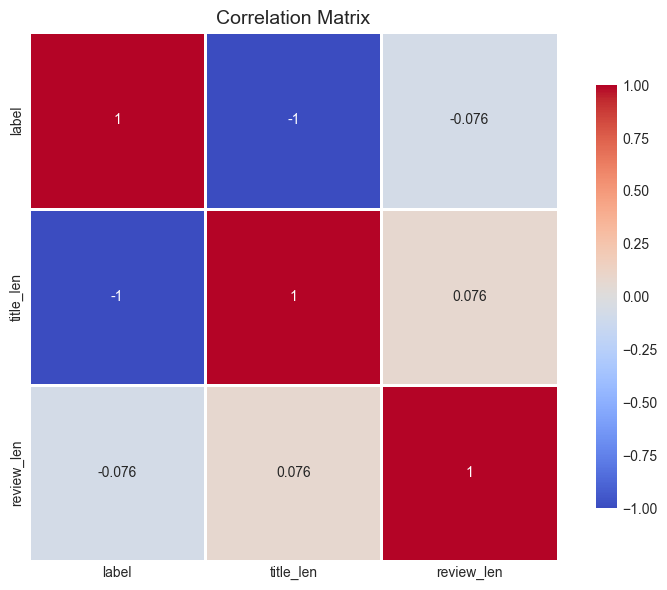

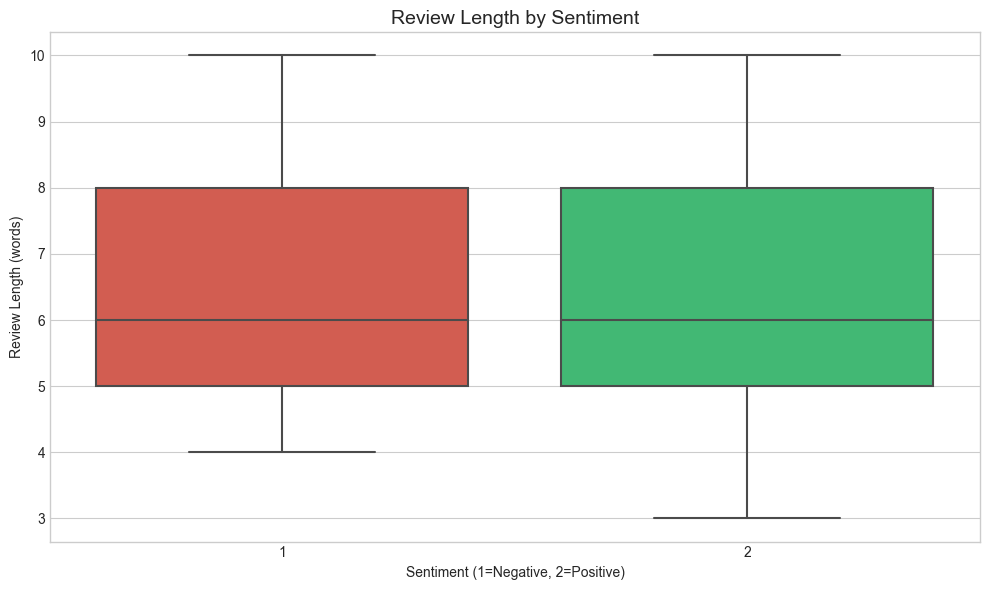

In [10]:
# Correlation analysis
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Create features for correlation
df_corr = df_train.copy()
df_corr['title_len'] = df_corr['title'].astype(str).str.len()
df_corr['review_len'] = df_corr['review_length']

# Calculate correlation matrix
corr_matrix = df_corr[['label', 'title_len', 'review_len']].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Scatter plot: review length vs sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='review_length', data=df_train, palette=['#e74c3c', '#2ecc71'])
plt.xlabel('Sentiment (1=Negative, 2=Positive)')
plt.ylabel('Review Length (words)')
plt.title('Review Length by Sentiment', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Save processed data for next notebooks
print("="*60)
print("SAVING PROCESSED DATA")
print("="*60)

# Create processed directory if not exists
os.makedirs('../data/processed', exist_ok=True)

# Save data
df_train.to_csv('../data/processed/train_processed.csv', index=False)
df_test.to_csv('../data/processed/test_processed.csv', index=False)

print(f"✅ Saved training data: ../data/processed/train_processed.csv")
print(f"✅ Saved test data: ../data/processed/test_processed.csv")

# Save EDA figures
os.makedirs('../outputs/figures', exist_ok=True)

print(f"\n📊 EDA complete! Ready for next notebook.")

SAVING PROCESSED DATA
✅ Saved training data: ../data/processed/train_processed.csv
✅ Saved test data: ../data/processed/test_processed.csv

📊 EDA complete! Ready for next notebook.
